In [ ]:
# Cellule 1 : Importations
# Importations de base et Keras/TensorFlow
from google.colab import drive
import tensorflow as tf
from tensorflow.keras import layers, models, backend as K
from tensorflow.keras.metrics import Recall, AUC 
from sklearn.model_selection import train_test_split
from PIL import Image
import os
import numpy as np from numpy as np
import random
import cv2
import matplotlib.pyplot as plt   import matplotlib.pyplot  as plt import time  driv.mount('/content/drive')   from scipy.spacial .distance
import time 

# Importations pour métriques post-entraînement
from scipy.spatial.distance import directed_hausdorff # Pour la distance de Hausdorff

# Montage de Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Cellule 2 : Fonctions d'augmentation


def rotateImage(image, angle):
    image_center = tuple(np.array(image.shape[1::-1])/2)
    rot_mat = cv2.getRotationMatrix2D(image_center, angle, 1.0)
    
    return cv2.warpAffine(image, rot_mat, image.shape[1::-1], flags=cv2.INTER_LINEAR)

def bruit(image):
    # Ajoute du bruit gaussien aléatoire
    
    image_float = image.astype(np.float32)
    noise = np.random.randn(*image.shape) * random.randint(5, 30)
    noisy_image = np.clip(image_float + noise, 0, 255)
    return noisy_image.astype(np.uint8)

def change_gamma(image, alpha=1.0, beta=0.0):
    # Ajuste la luminosité (beta) et le contraste (alpha)
   
    image_float = image.astype(np.float32)
    adjusted_image = np.clip(alpha * image_float + beta, 0, 255)
    return adjusted_image.astype(np.uint8)

def color(image, alpha=20):
    # Ajoute une variation de couleur aléatoire
    # Conversion en int32 pour éviter l'overflow/underflow pendant l'addition
    variation = np.random.randint(-alpha, alpha + 1, size=image.shape, dtype=np.int32)
    colored_image = np.clip(image.astype(np.int32) + variation, 0, 255)
    return colored_image.astype(np.uint8)

def random_change(image):
    # Applique aléatoirement certaines transformations 
    img = image.copy() # Travaille sur une copie
    if np.random.randint(2):
        img = change_gamma(img, random.uniform(0.8, 1.2), np.random.randint(-50, 50))
    if np.random.randint(2):
        img = bruit(img)
    if np.random.randint(2):
        img = color(img)
    return img

In [ ]:
# Cellule 3 : Définition du modèle Attention U-Net et Métriques

# --- Fonction Dice Coefficient --- 
def dice_coef(y_true, y_pred, smooth=1):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

# --- Bloc d'Attention --- 
def attention_block(x, gating, inter_channels):
    theta_x = layers.Conv2D(inter_channels, (1, 1), strides=(1, 1), padding='same', use_bias=False)(x)
    phi_g = layers.Conv2D(inter_channels, (1, 1), strides=(1, 1), padding='same', use_bias=True)(gating)

    concat = layers.Add()([theta_x, phi_g])
    concat = layers.Activation('relu')(concat)

    psi = layers.Conv2D(1, (1, 1), strides=(1, 1), padding='same', activation='sigmoid', use_bias=True)(concat)
    return layers.Multiply()([x, psi])

# --- Modèle Attention U-Net --- 
def model_attention_unet(nbr_filtres_base):
    entree = layers.Input(shape=(576, 560, 3), dtype='float32', name='InputImage')

    # Encodeur
    c1 = layers.Conv2D(nbr_filtres_base, 3, activation='relu', padding='same')(entree)
    c1 = layers.BatchNormalization()(c1)
    c1 = layers.Conv2D(nbr_filtres_base, 3, activation='relu', padding='same')(c1)
    bn1 = layers.BatchNormalization()(c1) # Sortie Bloc 1 pour skip connection
    p1 = layers.MaxPool2D()(bn1)

    c2 = layers.Conv2D(2 * nbr_filtres_base, 3, activation='relu', padding='same')(p1)
    c2 = layers.BatchNormalization()(c2)
    c2 = layers.Conv2D(2 * nbr_filtres_base, 3, activation='relu', padding='same')(c2)
    bn2 = layers.BatchNormalization()(c2) # Sortie Bloc 2 pour skip connection
    p2 = layers.MaxPool2D()(bn2)

    c3 = layers.Conv2D(4 * nbr_filtres_base, 3, activation='relu', padding='same')(p2)
    c3 = layers.BatchNormalization()(c3)
    c3 = layers.Conv2D(4 * nbr_filtres_base, 3, activation='relu', padding='same')(c3)
    bn3 = layers.BatchNormalization()(c3) # Sortie Bloc 3 pour skip connection
    p3 = layers.MaxPool2D()(bn3)

    c4 = layers.Conv2D(4 * nbr_filtres_base, 3, activation='relu', padding='same')(p3)
    c4 = layers.BatchNormalization()(c4)
    c4 = layers.Conv2D(4 * nbr_filtres_base, 3, activation='relu', padding='same')(c4)
    bn4 = layers.BatchNormalization()(c4) # Sortie Bloc 4 pour skip connection
    p4 = layers.MaxPool2D()(bn4)

    # Bottleneck
    cb = layers.Conv2D(8 * nbr_filtres_base, 3, activation='relu', padding='same')(p4)
    cb = layers.BatchNormalization()(cb)
    cb = layers.Conv2D(4 * nbr_filtres_base, 3, activation='relu', padding='same')(cb)
    bnb = layers.BatchNormalization()(cb)

    # Décodeur avec Attention
    u1_att = layers.UpSampling2D()(bnb)
    att1 = attention_block(bn4, u1_att, 4 * nbr_filtres_base) # Gating: upsamplé (u1_att), x: skip (bn4)
    concat1 = layers.Concatenate(axis=3)([u1_att, att1])
    dc1 = layers.Conv2D(8 * nbr_filtres_base, 3, activation='relu', padding='same')(concat1)
    dc1 = layers.BatchNormalization()(dc1)
    dc1 = layers.Conv2D(4 * nbr_filtres_base, 3, activation='relu', padding='same')(dc1)
    dbn1 = layers.BatchNormalization()(dc1)

    u2_att = layers.UpSampling2D()(dbn1)
    att2 = attention_block(bn3, u2_att, 2 * nbr_filtres_base) # Gating: u2_att, x: bn3
    concat2 = layers.Concatenate(axis=3)([u2_att, att2])
    dc2 = layers.Conv2D(4 * nbr_filtres_base, 3, activation='relu', padding='same')(concat2)
    dc2 = layers.BatchNormalization()(dc2)
    dc2 = layers.Conv2D(2 * nbr_filtres_base, 3, activation='relu', padding='same')(dc2)
    dbn2 = layers.BatchNormalization()(dc2)

    u3_att = layers.UpSampling2D()(dbn2)
    att3 = attention_block(bn2, u3_att, nbr_filtres_base) # Gating: u3_att, x: bn2
    concat3 = layers.Concatenate(axis=3)([u3_att, att3])
    dc3 = layers.Conv2D(2 * nbr_filtres_base, 3, activation='relu', padding='same')(concat3)
    dc3 = layers.BatchNormalization()(dc3)
    dc3 = layers.Conv2D(nbr_filtres_base, 3, activation='relu', padding='same')(dc3)
    dbn3 = layers.BatchNormalization()(dc3)

    u4_att = layers.UpSampling2D()(dbn3)
    att4 = attention_block(bn1, u4_att, nbr_filtres_base) # Gating: u4_att, x: bn1
    concat4 = layers.Concatenate(axis=3)([u4_att, att4])
    dc4 = layers.Conv2D(nbr_filtres_base, 3, activation='relu', padding='same')(concat4)
    dc4 = layers.BatchNormalization()(dc4)
    dc4 = layers.Conv2D(nbr_filtres_base, 3, activation='relu', padding='same')(dc4)
    dbn4 = layers.BatchNormalization()(dc4)

    sortie = layers.Conv2D(1, 1, activation='sigmoid', padding='same', name='OutputMask')(dbn4)

    return models.Model(inputs=entree, outputs=sortie)


# --- Métriques Keras personnalisées --- 
def iou_coef(y_true, y_pred, smooth=1e-6):
    """Coefficient IoU (Intersection over Union) ou Indice de Jaccard."""
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f) - intersection
    iou = (intersection + smooth) / (union + smooth)
    return iou



def specificity(y_true, y_pred):
    """Spécificité (True Negative Rate)."""
    neg_y_true = 1 - y_true
    neg_y_pred = 1 - y_pred
    fp = K.sum(K.cast(K.greater(y_pred, 0.5), 'float32') * K.cast(K.equal(y_true, 0), 'float32'))
    tn = K.sum(K.cast(K.less_equal(y_pred, 0.5), 'float32') * K.cast(K.equal(y_true, 0), 'float32'))
    specificity_val = tn / (tn + fp + K.epsilon())
    return specificity_val

In [ ]:
# Cellule 4 : Chargement, Augmentation et Division des Données 
# Utilise la même logique et les mêmes paramètres que UNETSIMPLE pour la comparabilité

# Chemins vers les données 
dir_images = '/content/drive/MyDrive/DRIVE/training/images/'
dir_mask = '/content/drive/MyDrive/DRIVE/training/1st_manual/' 

# Vérification existence dossiers
if not os.path.isdir(dir_images):
    raise ValueError(f"Le dossier d'images n'existe pas : {dir_images}")
if not os.path.isdir(dir_mask):
    raise ValueError(f"Le dossier de masques n'existe pas : {dir_mask}")

tab_images, tab_masks = [], []
target_height, target_width = 576, 560 # Taille d'entrée du modèle

print("Chargement et augmentation des données (standardisé)...")

# Boucle de chargement et d'augmentation 
for fichier in sorted(os.listdir(dir_images)):
    if fichier.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff')): 
        try: 
            img_path = os.path.join(dir_images, fichier)
            img_orig = cv2.imread(img_path)
            if img_orig is None: 
                 print(f"Attention: Impossible de lire {fichier}, ignoré.")
                 continue
            img_orig = img_orig[:target_height, :target_width]
            if img_orig.shape[0] != target_height or img_orig.shape[1] != target_width: 
                img_orig = cv2.resize(img_orig, (target_width, target_height), interpolation=cv2.INTER_AREA)

            num = fichier.split('_')[0]
            file_mask = os.path.join(dir_mask, num + '_manual1.gif')
            if not os.path.exists(file_mask): 
                print(f"Attention: Masque {file_mask} non trouvé pour {fichier}, ignoré.")
                continue

            img_mask_orig = np.array(Image.open(file_mask))
            if len(img_mask_orig.shape) == 3: img_mask_orig = img_mask_orig[:,:,0] 
            img_mask_orig = img_mask_orig[:target_height, :target_width]
            if img_mask_orig.shape[0] != target_height or img_mask_orig.shape[1] != target_width: 
                 img_mask_orig = cv2.resize(img_mask_orig, (target_width, target_height), interpolation=cv2.INTER_NEAREST)

            tab_images.append(img_orig)
            tab_masks.append(img_mask_orig)  
            # Augmentations (Rotation, Flip, Changements aléatoires)
            for angle in [0, 90, 180, 270]: 
                img_r = rotateImage(img_orig, angle)
                mask_rot_mat = cv2.getRotationMatrix2D(tuple(np.array(img_mask_orig.shape[1::-1])/2), angle, 1.0)
                img_mask_r = cv2.warpAffine(img_mask_orig, mask_rot_mat, img_mask_orig.shape[1::-1], flags=cv2.INTER_NEAREST)

                # Application des flips et changements aléatoires
                for flip_code in [-1, 0, 1]: 
                    for flip in [0, 1]: 
                        # Logique de flip standardisée 
                        if flip_code == -1 and flip == 0: 
                            img_f = cv2.flip(img_r, -1)
                            img_mask_f = cv2.flip(img_mask_r, -1)
                        elif flip_code != -1 and flip == 1: 
                            img_f = cv2.flip(img_r, flip_code)
                            img_mask_f = cv2.flip(img_mask_r, flip_code)
                        else: 
                            img_f = img_r.copy()
                            img_mask_f = img_mask_r.copy()

                        img_augmented = random_change(img_f) 
                        # Recadrage final après toutes les transformations
                        img_augmented = img_augmented[:target_height, :target_width]
                        img_mask_final = img_mask_f[:target_height, :target_width]

                        # Vérification finale des dimensions avant ajout
                        if img_augmented.shape[0] == target_height and img_augmented.shape[1] == target_width and \
                           img_mask_final.shape[0] == target_height and img_mask_final.shape[1] == target_width: 
                              tab_images.append(img_augmented) 
                              tab_masks.append(img_mask_final)

        except Exception as e: 
            print(f"Erreur pendant chargement/augmentation pour {fichier}: {e}") 

if len(tab_images) > 500:
    print(f"\nAttention: Plus de 500 images générées ({len(tab_images)}), limitation à 500.")
    indices = random.sample(range(len(tab_images)), 500)
    tab_images = [tab_images[i] for i in indices]
    tab_masks = [tab_masks[i] for i in indices]

print(f"\nChargement et augmentation terminés. Nombre total d'échantillons: {len(tab_images)}")
if not tab_images:
    raise SystemExit("Erreur: Aucune image/masque après chargement/augmentation.")

tab_images = np.array(tab_images, dtype=np.float32) / 255.0
tab_masks = np.array(tab_masks, dtype=np.float32) / 255.0
if len(tab_masks.shape) == 3:
    tab_masks = np.expand_dims(tab_masks, axis=-1)
    print(f"Dimension de canal ajoutée aux masques. Nouvelle forme : {tab_masks.shape}")

print(f"Forme finale des images : {tab_images.shape}")
print(f"Forme finale des masques : {tab_masks.shape}")

# Séparer les jeux de données ( 80% train, 15% val, 5% test interne)
# Utilisation de random_state=123 pour la reproductibilité et la comparabilité 
train_images, test_val_images, train_masks, test_val_masks = train_test_split(
    tab_images, tab_masks, test_size=0.2, random_state=123 # 80% train, 20% pour test+val
)
val_images, test_images_internal, val_masks, test_masks_internal = train_test_split(
    test_val_images, test_val_masks, test_size=0.25, random_state=123 
)

print(f"\nDonnées divisées :")
print(f"  Entraînement : {train_images.shape[0]} images, {train_masks.shape[0]} masques")
print(f"  Validation   : {val_images.shape[0]} images, {val_masks.shape[0]} masques")
print(f"  Test Interne : {test_images_internal.shape[0]} images, {test_masks_internal.shape[0]} masques") 

# Libérer la mémoire 
del tab_images, tab_masks, test_val_images, test_val_masks

Chargement et augmentation des données (standardisé)...

Chargement et augmentation terminés. Nombre total d'échantillons: 500
Dimension de canal ajoutée aux masques. Nouvelle forme : (500, 576, 560, 1)
Forme finale des images : (500, 576, 560, 3)
Forme finale des masques : (500, 576, 560, 1)

Données divisées :
  Entraînement : 400 images, 400 masques
  Validation   : 75 images, 75 masques
  Test Interne : 25 images, 25 masques


In [ ]:
# Cellule 5 : Instanciation et Compilation du Modèle Spatial-AttVesNet

# Instancier le modèle Spatial-AttVesNet 
my_model_attention = model_attention_unet(64) # 64 filtres de base


my_model_attention.compile(optimizer='adam',
                           loss='binary_crossentropy',
                           metrics=['accuracy',
                                    dice_coef,
                                    iou_coef, 
                                    Recall(name='sensitivity'), 
                                    specificity, # Specificity
                                    AUC(name='auc_roc')]) 


print("\nRésumé du modèle Attention U-Net qui sera entraîné :")
my_model_attention.summary()


Résumé du modèle Attention U-Net qui sera entraîné :


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ InputImage          │ (None, 576, 560,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 576, 560,  │      1,792 │ InputImage[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 576, 560,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 576, 560,  │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 576, 560,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 288, 280,  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 288, 280,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 288, 280,  │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 288, 280,  │    147,584 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 288, 280,  │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 144, 140,  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 144, 140,  │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 144, 140,  │      1,024 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 144, 140,  │    590,080 │ batch_normalizat… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 144, 140,  │      1,024 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 72, 70,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 72, 70,    │    590,080 │ max_pooling2d_2[

 Total params: 10,416,709 (39.74 MB)

 Trainable params: 10,409,413 (39.71 MB)

 Non-trainable params: 7,296 (28.50 KB)

In [ ]:
# Cellule 6 : Configuration et Lancement de l'Entraînement

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Chemin pour sauvegarder le meilleur modèle Spatial-AttVesNet
checkpoint_filepath_attention = '/content/drive/MyDrive/best_unet_attention_ep75_b4.h5' 

early_stopping_att = EarlyStopping(monitor='val_dice_coef', patience=15, verbose=1, mode='max', restore_best_weights=True)

# Callback ModelCheckpoint 
model_checkpoint_att = ModelCheckpoint(filepath=checkpoint_filepath_attention,
                                       save_weights_only=False,
                                       monitor='val_dice_coef',
                                       mode='max',
                                       save_best_only=True,
                                       verbose=1)

# Paramètres d'entraînement 
EPOCHS = 75
BATCH_SIZE = 4

print(f"\n--- Début de l'entraînement Attention U-Net ({EPOCHS} époques, batch size {BATCH_SIZE}) ---")
print(f"Early Stopping surveille '{early_stopping_att.monitor}' ({early_stopping_att.mode}) avec patience {early_stopping_att.patience}.")
print(f"Model Checkpoint sauvegardera le meilleur modèle selon '{model_checkpoint_att.monitor}' dans '{checkpoint_filepath_attention}'.")

start_training_time_att = time.time()

# Entraîner le modèle Attention U-Net
history_attention = my_model_attention.fit(train_images, train_masks,
                                           epochs=EPOCHS,
                                           batch_size=BATCH_SIZE,
                                           validation_data=(val_images, val_masks), 
                                           callbacks=[early_stopping_att, model_checkpoint_att],
                                           verbose=1)

end_training_time_att = time.time()
training_runtime_att = end_training_time_att - start_training_time_att
print(f"\n--- Entraînement Attention U-Net terminé (potentiellement avant {EPOCHS} époques) ---")
print(f"Temps d'exécution total de l'entraînement (Runtime) : {training_runtime_att:.2f} secondes ({training_runtime_att/60:.2f} minutes)")
print(f"Le meilleur modèle Attention U-Net a été sauvegardé à : {checkpoint_filepath_attention}")



--- Début de l'entraînement Attention U-Net (75 époques, batch size 4) ---
Early Stopping surveille 'val_dice_coef' (max) avec patience 15.
Model Checkpoint sauvegardera le meilleur modèle selon 'val_dice_coef' dans '/content/drive/MyDrive/best_unet_attention_ep75_b4.h5'.
Epoch 1/75
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 905ms/step - accuracy: 0.7153 - auc_roc: 0.7163 - dice_coef: 0.1915 - iou_coef: 0.1063 - loss: 0.6037 - sensitivity: 0.5811 - specificity: 0.7282
Epoch 1: val_dice_coef improved from -inf to 0.16456, saving model to /content/drive/MyDrive/best_unet_attention_ep75_b4.h5


100/100 ━━━━━━━━━━━━━━━━━━━━ 256s 2s/step - accuracy: 0.7164 - auc_roc: 0.7169 - dice_coef: 0.1919 - iou_coef: 0.1065 - loss: 0.6025 - sensitivity: 0.5807 - specificity: 0.7294 - val_accuracy: 0.1348 - val_auc_roc: 0.5338 - val_dice_coef: 0.1646 - val_iou_coef: 0.0897 - val_loss: 14.2621 - val_sensitivity: 0.9682 - val_specificity: 0.0542
Epoch 2/75
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 904ms/step - accuracy: 0.9382 - auc_roc: 0.8861 - dice_coef: 0.3630 - iou_coef: 0.2224 - loss: 0.2489 - sensitivity: 0.4783 - specificity: 0.9825
Epoch 2: val_dice_coef did not improve from 0.16456
100/100 ━━━━━━━━━━━━━━━━━━━━ 101s 1s/step - accuracy: 0.9382 - auc_roc: 0.8861 - dice_coef: 0.3634 - iou_coef: 0.2227 - loss: 0.2486 - sensitivity: 0.4783 - specificity: 0.9825 - val_accuracy: 0.9111 - val_auc_roc: 0.6535 - val_dice_coef: 0.0239 - val_iou_coef: 0.0121 - val_loss: 0.4007 - val_sensitivity: 2.5317e-05 - val_specificity: 0.9992
Epoch 3/75
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 907ms/step - accuracy: 0.9485 -

100/100 ━━━━━━━━━━━━━━━━━━━━ 148s 1s/step - accuracy: 0.9526 - auc_roc: 0.9448 - dice_coef: 0.5490 - iou_coef: 0.3791 - loss: 0.1418 - sensitivity: 0.5812 - specificity: 0.9882 - val_accuracy: 0.9168 - val_auc_roc: 0.8524 - val_dice_coef: 0.2402 - val_iou_coef: 0.1368 - val_loss: 0.2429 - val_sensitivity: 0.1174 - val_specificity: 0.9941
Epoch 5/75
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 909ms/step - accuracy: 0.9532 - auc_roc: 0.9483 - dice_coef: 0.5743 - iou_coef: 0.4038 - loss: 0.1357 - sensitivity: 0.5997 - specificity: 0.9877
Epoch 5: val_dice_coef improved from 0.24024 to 0.43071, saving model to /content/drive/MyDrive/best_unet_attention_ep75_b4.h5


100/100 ━━━━━━━━━━━━━━━━━━━━ 138s 1s/step - accuracy: 0.9533 - auc_roc: 0.9483 - dice_coef: 0.5744 - iou_coef: 0.4038 - loss: 0.1357 - sensitivity: 0.5998 - specificity: 0.9877 - val_accuracy: 0.9375 - val_auc_roc: 0.9182 - val_dice_coef: 0.4307 - val_iou_coef: 0.2753 - val_loss: 0.1842 - val_sensitivity: 0.3008 - val_specificity: 0.9991
Epoch 6/75
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 909ms/step - accuracy: 0.9549 - auc_roc: 0.9523 - dice_coef: 0.5953 - iou_coef: 0.4248 - loss: 0.1295 - sensitivity: 0.6172 - specificity: 0.9878
Epoch 6: val_dice_coef improved from 0.43071 to 0.52547, saving model to /content/drive/MyDrive/best_unet_attention_ep75_b4.h5


100/100 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.9549 - auc_roc: 0.9523 - dice_coef: 0.5953 - iou_coef: 0.4248 - loss: 0.1295 - sensitivity: 0.6173 - specificity: 0.9878 - val_accuracy: 0.9468 - val_auc_roc: 0.9352 - val_dice_coef: 0.5255 - val_iou_coef: 0.3577 - val_loss: 0.1561 - val_sensitivity: 0.4250 - val_specificity: 0.9973
Epoch 7/75
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 909ms/step - accuracy: 0.9571 - auc_roc: 0.9573 - dice_coef: 0.6138 - iou_coef: 0.4436 - loss: 0.1224 - sensitivity: 0.6359 - specificity: 0.9882
Epoch 7: val_dice_coef improved from 0.52547 to 0.59293, saving model to /content/drive/MyDrive/best_unet_attention_ep75_b4.h5


...

100/100 ━━━━━━━━━━━━━━━━━━━━ 149s 1s/step - accuracy: 0.9887 - auc_roc: 0.9985 - dice_coef: 0.9084 - iou_coef: 0.8322 - loss: 0.0263 - sensitivity: 0.9341 - specificity: 0.9940 - val_accuracy: 0.9675 - val_auc_roc: 0.9407 - val_dice_coef: 0.7949 - val_iou_coef: 0.6613 - val_loss: 0.1481 - val_sensitivity: 0.7916 - val_specificity: 0.9845
Epoch 67/75
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 911ms/step - accuracy: 0.9884 - auc_roc: 0.9984 - dice_coef: 0.9067 - iou_coef: 0.8295 - loss: 0.0268 - sensitivity: 0.9337 - specificity: 0.9937
Epoch 67: val_dice_coef did not improve from 0.79494
100/100 ━━━━━━━━━━━━━━━━━━━━ 135s 1s/step - accuracy: 0.9884 - auc_roc: 0.9984 - dice_coef: 0.9068 - iou_coef: 0.8296 - loss: 0.0268 - sensitivity: 0.9338 - specificity: 0.9937 - val_accuracy: 0.9678 - val_auc_roc: 0.9413 - val_dice_coef: 0.7938 - val_iou_coef: 0.6598 - val_loss: 0.1427 - val_sensitivity: 0.7814 - val_specificity: 0.9858
Epoch 68/75
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 912ms/step - accuracy: 0.9889 - a

100/100 ━━━━━━━━━━━━━━━━━━━━ 148s 1s/step - accuracy: 0.9893 - auc_roc: 0.9986 - dice_coef: 0.9128 - iou_coef: 0.8396 - loss: 0.0249 - sensitivity: 0.9387 - specificity: 0.9942 - val_accuracy: 0.9681 - val_auc_roc: 0.9378 - val_dice_coef: 0.7953 - val_iou_coef: 0.6620 - val_loss: 0.1498 - val_sensitivity: 0.7731 - val_specificity: 0.9869
Epoch 70/75
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 911ms/step - accuracy: 0.9892 - auc_roc: 0.9986 - dice_coef: 0.9135 - iou_coef: 0.8408 - loss: 0.0250 - sensitivity: 0.9385 - specificity: 0.9942
Epoch 70: val_dice_coef improved from 0.79533 to 0.79552, saving model to /content/drive/MyDrive/best_unet_attention_ep75_b4.h5


100/100 ━━━━━━━━━━━━━━━━━━━━ 139s 1s/step - accuracy: 0.9892 - auc_roc: 0.9986 - dice_coef: 0.9135 - iou_coef: 0.8408 - loss: 0.0250 - sensitivity: 0.9385 - specificity: 0.9942 - val_accuracy: 0.9669 - val_auc_roc: 0.9425 - val_dice_coef: 0.7955 - val_iou_coef: 0.6621 - val_loss: 0.1498 - val_sensitivity: 0.8052 - val_specificity: 0.9825
Epoch 71/75
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 911ms/step - accuracy: 0.9893 - auc_roc: 0.9986 - dice_coef: 0.9139 - iou_coef: 0.8415 - loss: 0.0248 - sensitivity: 0.9394 - specificity: 0.9942
Epoch 71: val_dice_coef did not improve from 0.79552
100/100 ━━━━━━━━━━━━━━━━━━━━ 138s 1s/step - accuracy: 0.9893 - auc_roc: 0.9986 - dice_coef: 0.9139 - iou_coef: 0.8415 - loss: 0.0248 - sensitivity: 0.9394 - specificity: 0.9942 - val_accuracy: 0.9680 - val_auc_roc: 0.9320 - val_dice_coef: 0.7908 - val_iou_coef: 0.6559 - val_loss: 0.1563 - val_sensitivity: 0.7510 - val_specificity: 0.9890
Epoch 72/75
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 911ms/step - accuracy: 0.9895 - a

100/100 ━━━━━━━━━━━━━━━━━━━━ 152s 1s/step - accuracy: 0.9898 - auc_roc: 0.9988 - dice_coef: 0.9185 - iou_coef: 0.8494 - loss: 0.0237 - sensitivity: 0.9430 - specificity: 0.9944 - val_accuracy: 0.9681 - val_auc_roc: 0.9398 - val_dice_coef: 0.7962 - val_iou_coef: 0.6632 - val_loss: 0.1489 - val_sensitivity: 0.7819 - val_specificity: 0.9861
Epoch 74/75
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 912ms/step - accuracy: 0.9902 - auc_roc: 0.9988 - dice_coef: 0.9199 - iou_coef: 0.8517 - loss: 0.0228 - sensitivity: 0.9443 - specificity: 0.9947
Epoch 74: val_dice_coef improved from 0.79620 to 0.79793, saving model to /content/drive/MyDrive/best_unet_attention_ep75_b4.h5


100/100 ━━━━━━━━━━━━━━━━━━━━ 107s 1s/step - accuracy: 0.9902 - auc_roc: 0.9988 - dice_coef: 0.9199 - iou_coef: 0.8517 - loss: 0.0228 - sensitivity: 0.9443 - specificity: 0.9947 - val_accuracy: 0.9681 - val_auc_roc: 0.9372 - val_dice_coef: 0.7979 - val_iou_coef: 0.6656 - val_loss: 0.1539 - val_sensitivity: 0.7812 - val_specificity: 0.9862
Epoch 75/75
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 912ms/step - accuracy: 0.9902 - auc_roc: 0.9988 - dice_coef: 0.9213 - iou_coef: 0.8542 - loss: 0.0228 - sensitivity: 0.9451 - specificity: 0.9946
Epoch 75: val_dice_coef did not improve from 0.79793
100/100 ━━━━━━━━━━━━━━━━━━━━ 102s 1s/step - accuracy: 0.9902 - auc_roc: 0.9988 - dice_coef: 0.9213 - iou_coef: 0.8542 - loss: 0.0228 - sensitivity: 0.9450 - specificity: 0.9946 - val_accuracy: 0.9682 - val_auc_roc: 0.9363 - val_dice_coef: 0.7979 - val_iou_coef: 0.6656 - val_loss: 0.1557 - val_sensitivity: 0.7776 - val_specificity: 0.9866
Restoring model weights from the end of the best epoch: 74.

--- Entraînement


--- Génération des graphiques de l'historique d'entraînement (Attention U-Net) ---


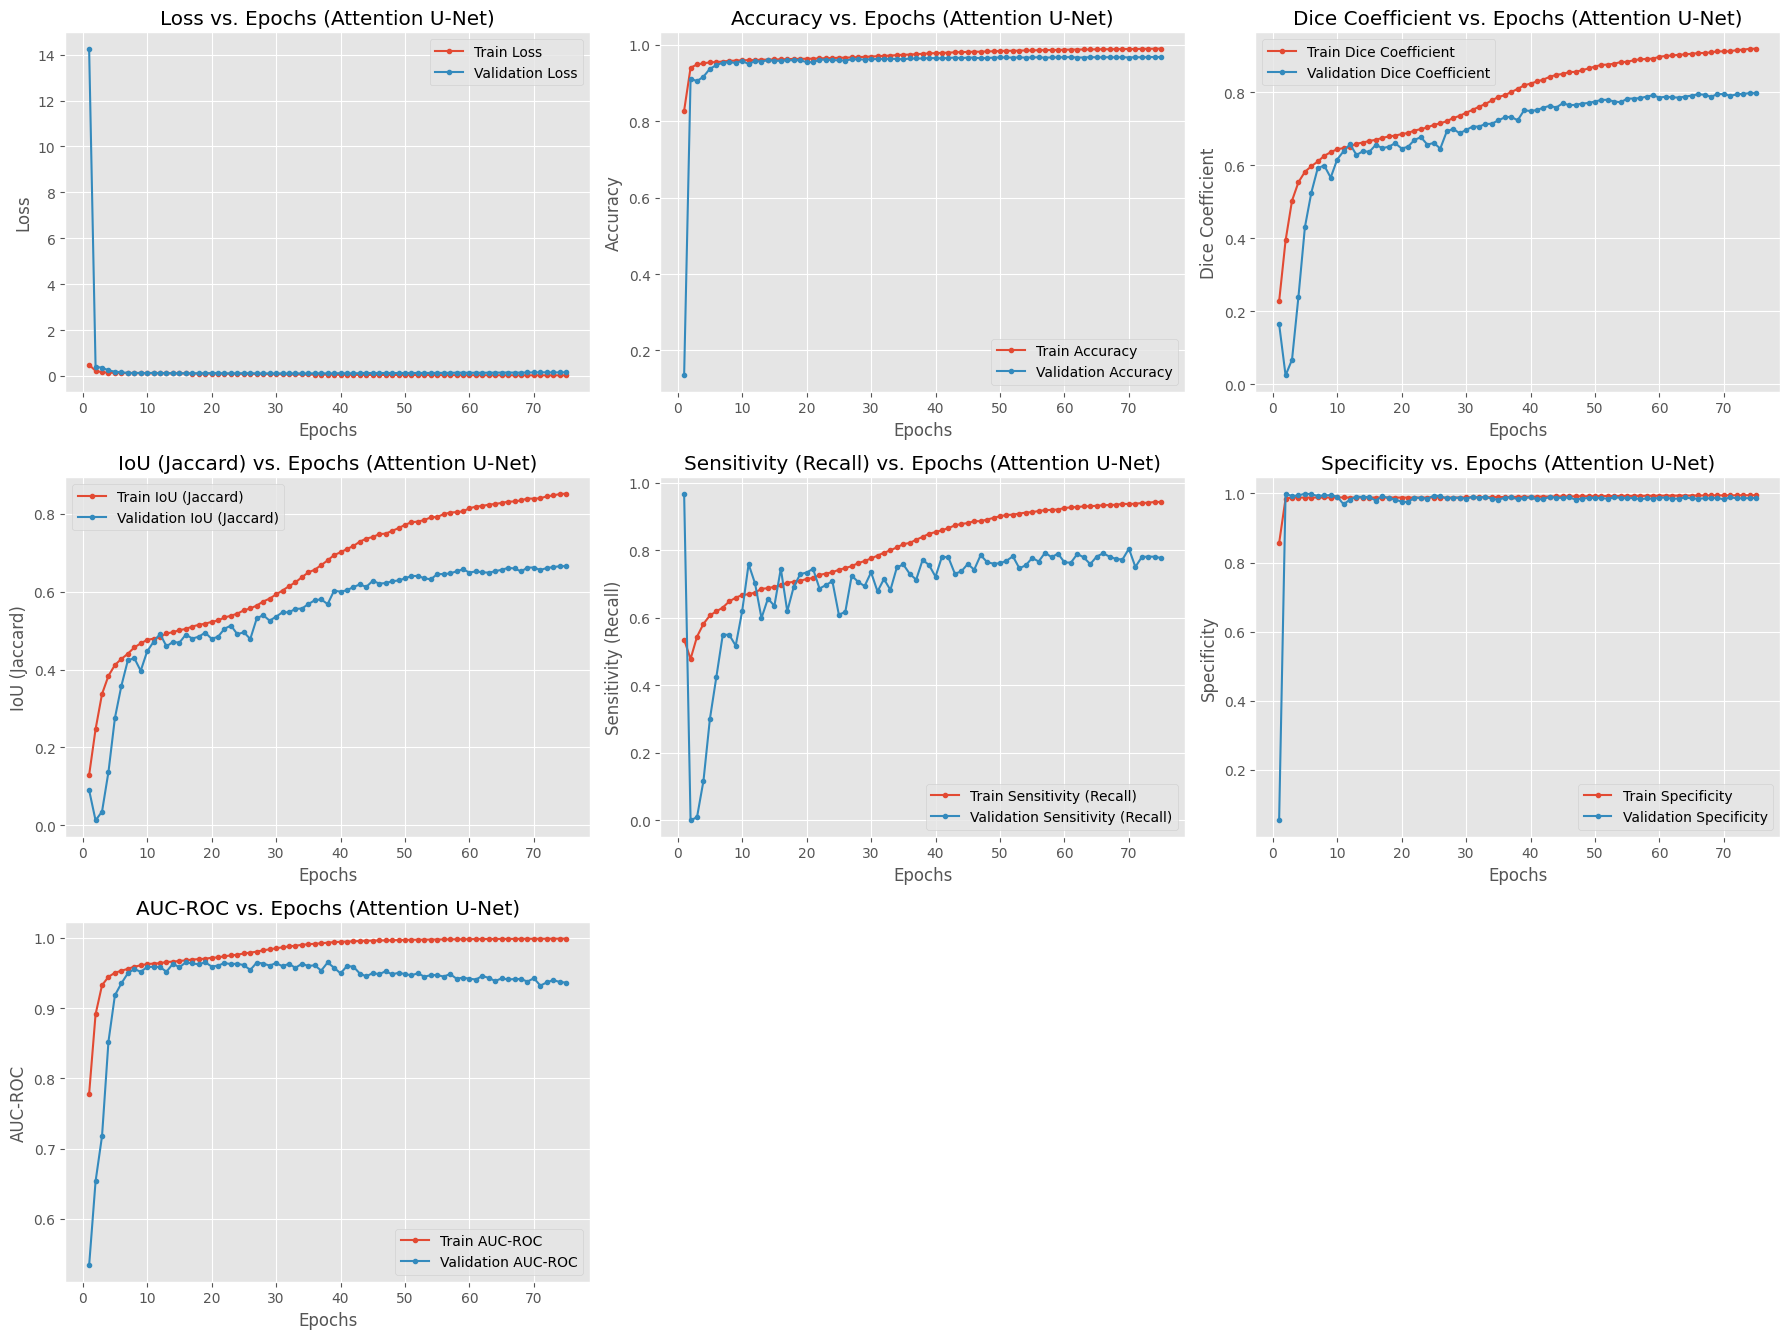


--- Valeurs finales des métriques (Attention U-Net - meilleure époque si EarlyStopping) ---
--- Loss ---
  Train      : 0.0230
  Validation : 0.1557
--- Accuracy ---
  Train      : 0.9901
  Validation : 0.9682
--- Dice Coefficient ---
  Train      : 0.9201
  Validation : 0.7979
--- IoU (Jaccard) ---
  Train      : 0.8521
  Validation : 0.6656
--- Sensitivity (Recall) ---
  Train      : 0.9437
  Validation : 0.7776
--- Specificity ---
  Train      : 0.9946
  Validation : 0.9866
--- AUC-ROC ---
  Train      : 0.9988
  Validation : 0.9363


In [ ]:
# Cellule 7 : Visualisation de l'Historique d'Entraînement

print("\n--- Génération des graphiques de l'historique d'entraînement (Attention U-Net) ---")

history_dict_att = history_attention.history 

metrics_to_plot = {
    'loss': 'Loss',
    'accuracy': 'Accuracy',
    'dice_coef': 'Dice Coefficient',
    'iou_coef': 'IoU (Jaccard)',
    'sensitivity': 'Sensitivity (Recall)',
    'specificity': 'Specificity',
    'auc_roc': 'AUC-ROC'
}

num_metrics = len(metrics_to_plot)
num_cols = 3
num_rows = (num_metrics + num_cols - 1) // num_cols

plt.style.use('ggplot')
fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(num_cols * 6, num_rows * 4.5))
axes = axes.flatten()

plot_index = 0
for metric_key, metric_name in metrics_to_plot.items():
    if plot_index >= len(axes): break 
    ax = axes[plot_index]
    if metric_key in history_dict_att:
        epochs_range = range(1, len(history_dict_att[metric_key]) + 1) 
        ax.plot(epochs_range, history_dict_att[metric_key], label=f'Train {metric_name}', marker='.')
        val_metric_key = f'val_{metric_key}'
        if val_metric_key in history_dict_att:
            ax.plot(epochs_range, history_dict_att[val_metric_key], label=f'Validation {metric_name}', marker='.')
        else:
            print(f"Note : Pas de données de validation trouvées pour '{val_metric_key}'")
        ax.set_title(f'{metric_name} vs. Epochs (Attention U-Net)') 
        ax.set_xlabel('Epochs')
        ax.set_ylabel(metric_name)
        ax.legend()
        plot_index += 1
    else:
        print(f"Attention : Métrique '{metric_key}' non trouvée dans l'historique Attention U-Net.")


for i in range(plot_index, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

print("\n--- Valeurs finales des métriques (Attention U-Net - meilleure époque si EarlyStopping) ---")
final_epoch_att = len(history_dict_att.get('loss', []))
if final_epoch_att > 0:
  for metric_key, metric_name in metrics_to_plot.items():
      if metric_key in history_dict_att: 
          print(f"--- {metric_name} ---")
          train_val = history_dict_att.get(metric_key, [np.nan])[-1] 
          val_val_key = f'val_{metric_key}'
          val_val = history_dict_att.get(val_val_key, [np.nan])[-1]
          print(f"  Train      : {train_val:.4f}")
          print(f"  Validation : {val_val:.4f}")
else:
  print("L'entraînement n'a pas produit d'historique.")

In [ ]:
# Cellule 8 : Évaluation Post-Entraînement sur le Test Interne

print("\n--- Évaluation post-entraînement sur l'ensemble de test interne (Spatial-AttVesNet) ---")


num_test_internal_samples_att = len(test_images_internal) 
if num_test_internal_samples_att > 0:
    print(f"Calcul du temps d'inférence sur {num_test_internal_samples_att} images de test interne...")
    start_inference_time_int_att = time.time()
    inference_batch_size_int_att = min(BATCH_SIZE, num_test_internal_samples_att) 
    predictions_prob_test_int_att = my_model_attention.predict(test_images_internal, batch_size=inference_batch_size_int_att)
    end_inference_time_int_att = time.time()

    total_inference_time_int_att = end_inference_time_int_att - start_inference_time_int_att
    avg_inference_time_per_image_int_att = total_inference_time_int_att / num_test_internal_samples_att
    print(f"  Temps d'inférence total (test interne): {total_inference_time_int_att:.4f} s")
    print(f"  Temps d'inférence moyen par image (test interne): {avg_inference_time_per_image_int_att:.6f} s")

    
    print(f"\nCalcul de la distance de Hausdorff (test interne)...\n")
    predictions_binary_test_int_att = (predictions_prob_test_int_att > 0.5).astype(np.uint8)
    test_masks_binary_int_att = (test_masks_internal > 0.5).astype(np.uint8) 

    hausdorff_distances_int_att = []
    for i in range(num_test_internal_samples_att):
        gt_mask = test_masks_binary_int_att[i].squeeze()
        pred_mask = predictions_binary_test_int_att[i].squeeze()
        coords_gt = np.argwhere(gt_mask > 0)
        coords_pred = np.argwhere(pred_mask > 0)

        if coords_gt.shape[0] > 0 and coords_pred.shape[0] > 0:
            try:
                
                hd1 = directed_hausdorff(coords_gt, coords_pred)[0]
                hd2 = directed_hausdorff(coords_pred, coords_gt)[0]
                hausdorff_distances_int_att.append(max(hd1, hd2)) 
            except Exception as e:
                print(f"Erreur calcul Hausdorff pour index {i}: {e}")
                hausdorff_distances_int_att.append(np.nan) 
        elif coords_gt.shape[0] == 0 and coords_pred.shape[0] == 0:
            
            hausdorff_distances_int_att.append(0.0)
        else:
            hausdorff_distances_int_att.append(np.nan)

    valid_distances_int_att = [d for d in hausdorff_distances_int_att if not np.isnan(d)]
    if valid_distances_int_att:
        avg_hausdorff_int_att = np.mean(valid_distances_int_att)
        std_hausdorff_int_att = np.std(valid_distances_int_att)
        print(f"  Distance de Hausdorff Moyenne (Test Interne, {len(valid_distances_int_att)} paires valides): {avg_hausdorff_int_att:.4f}")
        print(f"  Distance de Hausdorff Écart-type (Test Interne, {len(valid_distances_int_att)} paires valides): {std_hausdorff_int_att:.4f}")
        print(f"  (Note: Les paires où un masque est vide et l'autre non sont exclues du calcul.)")
    else:
        print("  Impossible de calculer une distance de Hausdorff moyenne (test interne) car aucune paire valide n'a été trouvée.")
else:
    print("Ensemble de test interne vide, impossible d'évaluer.")


--- Évaluation post-entraînement sur l'ensemble de test interne (Attention U-Net) ---
Calcul du temps d'inférence sur 25 images de test interne...
7/7 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step
  Temps d'inférence total (test interne): 15.6849 s
  Temps d'inférence moyen par image (test interne): 0.627394 s

Calcul de la distance de Hausdorff (test interne)...

  Distance de Hausdorff Moyenne (Test Interne, 25 paires valides): 36.9400
  Distance de Hausdorff Écart-type (Test Interne, 25 paires valides): 10.8478
  (Note: Les paires où un masque est vide et l'autre non sont exclues du calcul.)


In [ ]:
# Cellule 9 : Prédictions sur le Jeu de Test(DRIVE)

print("\n--- Prédictions sur le dossier de test externe DRIVE (Attention U-Net) ---")

dir_drive_test_images = '/content/drive/MyDrive/DRIVE/test/images/'
dir_drive_predictions_attention = '/content/drive/MyDrive/DRIVE_predictions_unet_attention/' 
os.makedirs(dir_drive_predictions_attention, exist_ok=True) 

if not os.path.isdir(dir_drive_test_images):
    print(f"Attention: Dossier de test externe DRIVE {dir_drive_test_images} non trouvé. Section ignorée.")
else:
    print(f"Chargement des images depuis: {dir_drive_test_images}")
    print(f"Sauvegarde des prédictions Attention U-Net dans: {dir_drive_predictions_attention}")

    fichiers_drive_test = sorted(os.listdir(dir_drive_test_images))
    processed_drive_test_count_att = 0
    for fichier in fichiers_drive_test:
         if fichier.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff')):
            try:
                img_path = os.path.join(dir_drive_test_images, fichier)
                image_ext = cv2.imread(img_path)
                if image_ext is None:
                    print(f"Attention: Impossible de lire {fichier} (DRIVE test), ignoré.")
                    continue

                # Redimensionner/Recadrer à target_height x target_width (taille d'entrée du modèle)
                image_ext_resized = image_ext[:target_height, :target_width]
                if image_ext_resized.shape[0] != target_height or image_ext_resized.shape[1] != target_width:
                    image_ext_resized = cv2.resize(image_ext, (target_width, target_height), interpolation=cv2.INTER_AREA)

                # Normaliser et ajouter dimension batch
                image_ext_norm = np.array(image_ext_resized, dtype=np.float32) / 255.0
                image_ext_batch = image_ext_norm[np.newaxis, ...]

                # Prédiction avec le modèle Spatial-AttVesNet 
                prediction_prob_drive_att = my_model_attention.predict(image_ext_batch)[0] 

                
                # Sauvegarde à la taille de prédiction (576x560)
                mask_out_drive_att = (prediction_prob_drive_att * 255.0).astype(np.uint8)

                if len(mask_out_drive_att.shape) == 3 and mask_out_drive_att.shape[-1] == 1:
                    mask_out_drive_att_squeezed = mask_out_drive_att.squeeze()
                else:
                    mask_out_drive_att_squeezed = mask_out_drive_att

                base_name = os.path.splitext(fichier)[0]
                save_path_drive_att = os.path.join(dir_drive_predictions_attention, f"pred_attention_{base_name}.png")

                cv2.imwrite(save_path_drive_att, mask_out_drive_att_squeezed)
                processed_drive_test_count_att += 1
            except Exception as e:
                print(f"Erreur lors de la prédiction pour {fichier} (DRIVE test - Attention): {e}")

    print(f"\n{processed_drive_test_count_att} prédictions (Attention U-Net) sauvegardées dans {dir_drive_predictions_attention}")


--- Prédictions sur le dossier de test externe DRIVE (Attention U-Net) ---
Chargement des images depuis: /content/drive/MyDrive/DRIVE/test/images/
Sauvegarde des prédictions Attention U-Net dans: /content/drive/MyDrive/DRIVE_predictions_unet_attention/
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━

In [ ]:
# Cellule 10 : Sauvegarde du Modèle Final

# Enregistrer l'état final du modèle Spatial-AttVesNet
model_save_path_final_attention = '/content/drive/MyDrive/final_unet_attention_ep75_b4.h5' 

my_model_attention.save(model_save_path_final_attention)
print(f"\nModèle final (Attention U-Net) enregistré sous : {model_save_path_final_attention}")
print(f"Le MEILLEUR modèle Attention U-Net basé sur '{model_checkpoint_att.monitor}' est dans : {checkpoint_filepath_attention}")

print("\n--- Fin du script Attention U-Net ---") 
print("\print")


Modèle final (Attention U-Net) enregistré sous : /content/drive/MyDrive/final_unet_attention_ep75_b4.h5
Le MEILLEUR modèle Attention U-Net basé sur 'val_dice_coef' est dans : /content/drive/MyDrive/best_unet_attention_ep75_b4.h5

--- Fin du script Attention U-Net ---
